# Iteración Final (V3) — Análisis de Errores, Curva de Ganancia y Validación

## Caso Práctico — Empresa de Telecomunicaciones
## Prácticas Aplicadas 2026

---

## Qué añade esta iteración respecto a V2

El modelo V2 (LR + Features V2) alcanzó **AUC = 0.703** sin leakage. Esta iteración no busca subir el AUC,
sino **entender mejor el modelo** y comunicar sus resultados en lenguaje de negocio:

1. **Análisis de falsos negativos** — ¿Quiénes son los churners que el modelo no detecta? ¿Tienen algo en común?
2. **Curva de ganancia (Gain/Lift)** — ¿Si llamo al 10% de clientes con mayor score, a qué % del churn llego?
3. **Densidad de ratio_estres** — Validación visual de la hipótesis estrella del proyecto.
4. **Discusión: Walk-Forward Validation** — Por qué nuestro split es correcto y qué mejoraría una validación temporal.

Estos análisis conectan directamente con lo que pide el profesor:
> *'Analizar errores. Comparar falsos negativos frente a verdaderos positivos.
> Ver si el modelo falla más en ciertas zonas. Traducir resultados a acciones de negocio.'*


## 1. Librerías y carga de datos


In [6]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
PALETTE = {'churn': '#E85C4C', 'no_churn': '#4C9BE8'}

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.load import load_all
from src.clean import clean_all

RANDOM_STATE = 42
print('Librerías cargadas')


Librerías cargadas


## 2. Reconstrucción del dataset panel con Features V2

Replicamos exactamente el pipeline de `modelo_features_v2.ipynb` para obtener
el mismo dataset y modelo sobre el que haremos el análisis de errores.


In [7]:
# Carga y limpieza
data  = load_all()
clean = clean_all(data, save=False)

clientes   = clean['clientes']
churn_raw  = clean['churn']
factura    = clean['facturacion']
soporte    = clean['soporte']
calidad    = clean['calidad']
encuestas  = clean['encuestas']
print('Datos cargados')


  CARGANDO DATASETS
[load] clientes:    10,150 filas x 14 columnas
[load] churn:       321,987 filas x 3 columnas
[load] facturacion: 326,816 filas x 14 columnas
[load] soporte:     308,487 filas x 13 columnas
[load] calidad:     1,096 filas x 12 columnas
[load] encuestas:   1,015 filas x 13 columnas

✅ Todos los datasets cargados correctamente

  LIMPIANDO DATASETS

[clean_clientes] Eliminados 150 duplicados exactos
[clean_clientes] 145 antigüedades negativas → 0
[clean_clientes] 10,150 → 10,000 filas | Nulos restantes: 1022
[clean_churn] 321,987 → 321,987 filas
[clean_facturacion] Eliminados 4829 duplicados exactos
[clean_facturacion] 9659 registros con importe_total nulo (se mantienen como NaN — posibles errores de sistema)
[clean_facturacion] 3636 registros con consumo_extra negativo (abonos/correcciones — se mantienen)
[clean_facturacion] 326,816 → 321,987 filas
[clean_soporte] Eliminados 4558 duplicados exactos
[clean_soporte] 4558 duraciones fuera de rango → NaN
[clean_soporte] 

In [8]:
# ── Feature engineering (igual que V2) ──────────────────────────────────────
factura['fecha'] = pd.to_datetime(factura['fecha'], format='mixed', dayfirst=True)
factura['ym']    = factura['fecha'].dt.to_period('M')
churn_raw['fecha'] = pd.to_datetime(churn_raw['fecha'], format='mixed', dayfirst=True)
churn_raw['ym']    = churn_raw['fecha'].dt.to_period('M')

# Lag 1 de facturación por cliente
fac_lag = (factura
    .sort_values(['cliente_id','ym'])
    .assign(
        impago_mes_lag1        = lambda d: d.groupby('cliente_id')['impago_flag'].shift(1),
        stress_mes_lag1        = lambda d: d.groupby('cliente_id')['stress_calidad_lag'].shift(1),
        dias_retraso_lag1      = lambda d: d.groupby('cliente_id')['dias_retraso_pago'].shift(1),
        consumo_extra_lag1     = lambda d: d.groupby('cliente_id')['consumo_extra'].shift(1),
        variacion_lag1         = lambda d: d.groupby('cliente_id')['variacion_consumo_pct'].shift(1),
    )
    [['cliente_id','ym','impago_mes_lag1','stress_mes_lag1',
      'dias_retraso_lag1','consumo_extra_lag1','variacion_lag1']]
)

# Rolling 3m
roll3 = (factura
    .sort_values(['cliente_id','ym'])
    .groupby('cliente_id')[['impago_flag','stress_calidad_lag','dias_retraso_pago','variacion_consumo_pct']]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    .rename(columns={
        'impago_flag':           'impago_roll3',
        'stress_calidad_lag':    'stress_roll3',
        'dias_retraso_pago':     'retraso_roll3',
        'variacion_consumo_pct': 'variacion_roll3',
    })
)
fac_lag = pd.concat([fac_lag, roll3], axis=1)

# Features de tendencia (V1)
fac_lag['racha_impagos_lag1'] = (
    factura.sort_values(['cliente_id','ym'])
    .groupby('cliente_id')['impago_flag']
    .transform(lambda s: s.shift(1).groupby((s.shift(1) == 0).cumsum()).cumcount())
)
fac_lag['sin_consumo_2m_lag1'] = (
    factura.sort_values(['cliente_id','ym'])
    .groupby('cliente_id')['consumo_extra']
    .transform(lambda s: (s.shift(1).rolling(2, min_periods=2).max() == 0).astype(int))
)

# Features V2 — ratio_estres
fac_lag['ratio_estres_lag1'] = (
    (fac_lag['dias_retraso_lag1'].fillna(0) + 1) /
    (fac_lag['stress_mes_lag1'].fillna(0.5) + 1)
)

print(f'Features panel: {fac_lag.shape}')


Features panel: (321987, 14)


In [9]:
# Soporte lag1
soporte['fecha_evento'] = pd.to_datetime(soporte['fecha_evento'], format='mixed', dayfirst=True)
soporte['ym'] = soporte['fecha_evento'].dt.to_period('M')

sop_mes = soporte.groupby(['cliente_id','ym']).agg(
    n_interacciones_mes = ('interaccion_id','count'),
    n_llamadas_baja_mes = ('motivo', lambda x: (x=='Baja/Portabilidad').sum()),
    critica_mes         = ('motivo', lambda x: int(x.isin(['Facturación','Baja/Portabilidad']).any())),
).reset_index()

# critica_pendiente se calcula directamente en sop_lag con shift(1)
# No necesitamos critica_resuelta_mes — la critica_pendiente_lag1 ya captura la señal

sop_lag = (
    sop_mes
    .sort_values(['cliente_id','ym'])
    .assign(
        interacc_lag1          = lambda d: d.groupby('cliente_id')['n_interacciones_mes'].shift(1),
        baja_lag1              = lambda d: d.groupby('cliente_id')['n_llamadas_baja_mes'].shift(1),
        critica_pendiente_lag1 = lambda d: d.groupby('cliente_id')['critica_mes'].shift(1),
    )
    [['cliente_id','ym','interacc_lag1','baja_lag1','critica_pendiente_lag1']]
)

# Calidad lag1
calidad['fecha'] = pd.to_datetime(calidad['fecha'], format='mixed', dayfirst=True)
calidad['ym']    = calidad['fecha'].dt.to_period('M')
cal_zona = calidad.groupby(['zona_id','ym']).agg(
    calidad_global_lag1 = ('indice_calidad_global','mean'),
    tasa_cortes_lag1    = ('tasa_cortes_pct','mean'),
    cobertura_5g_lag1   = ('cobertura_5g_pct','mean'),
).reset_index()

# Desplazar ym un mes hacia adelante para usarla como lag1 en el join
cal_zona_lag = cal_zona.copy()
cal_zona_lag['ym'] = cal_zona_lag['ym'] + 1

print(f'sop_lag: {sop_lag.shape}')
print(f'cal_zona_lag: {cal_zona_lag.shape}')
print('Soporte y calidad listos')


sop_lag: (179108, 5)
cal_zona_lag: (1080, 5)
Soporte y calidad listos


In [10]:
# Encuestas — sentimiento zonal lag1
# La columna de sentimiento se llama 'sent_text_latente' en el CSV
encuestas['fecha'] = pd.to_datetime(encuestas['fecha'], format='mixed', dayfirst=True)
encuestas['ym']    = encuestas['fecha'].dt.to_period('M')
enc_zona = (
    encuestas
    .groupby(['zona_id','ym'])['sent_text_latente']
    .mean()
    .reset_index(name='sentimiento_lag1')
)
enc_zona_lag = enc_zona.copy()
enc_zona_lag['ym'] = enc_zona_lag['ym'] + 1  # desplazar un mes (mismo patrón que calidad)

# Unir todo con churn_target
panel = churn_raw.merge(
    clientes[['cliente_id','zona_id','region','tipo_zona','tipo_plan',
              'edad','sexo','estado_civil','num_lineas',
              'ingreso_estimado','antiguedad_meses','descuento_activo']],
    on='cliente_id', how='left'
)
panel = panel.merge(fac_lag,    on=['cliente_id','ym'], how='left')
panel = panel.merge(sop_lag,    on=['cliente_id','ym'], how='left')
panel = panel.merge(
    cal_zona_lag[['zona_id','ym','calidad_global_lag1','tasa_cortes_lag1','cobertura_5g_lag1']],
    on=['zona_id','ym'], how='left'
)
panel = panel.merge(
    enc_zona_lag[['zona_id','ym','sentimiento_lag1']],
    on=['zona_id','ym'], how='left'
)

panel = panel.dropna(subset=['impago_mes_lag1'])  # quitar primer mes (no hay lag)
panel['churn'] = panel['churn'].astype(int)

print(f'Panel final: {panel.shape} | Tasa churn: {panel.churn.mean():.4f}')
print(f'Columnas: {panel.columns.tolist()}')


Panel final: (311987, 34) | Tasa churn: 0.0064
Columnas: ['cliente_id', 'fecha', 'churn', 'ym', 'zona_id', 'region', 'tipo_zona', 'tipo_plan', 'edad', 'sexo', 'estado_civil', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo', 'impago_mes_lag1', 'stress_mes_lag1', 'dias_retraso_lag1', 'consumo_extra_lag1', 'variacion_lag1', 'impago_roll3', 'stress_roll3', 'retraso_roll3', 'variacion_roll3', 'racha_impagos_lag1', 'sin_consumo_2m_lag1', 'ratio_estres_lag1', 'interacc_lag1', 'baja_lag1', 'critica_pendiente_lag1', 'calidad_global_lag1', 'tasa_cortes_lag1', 'cobertura_5g_lag1', 'sentimiento_lag1']


## 3. Entrenamiento del modelo V2 (LR + Features V2)

Split por cliente (80/20), mismo protocolo que las iteraciones anteriores.


In [11]:
# Split por cliente — mismo protocolo que V2
clientes_unicos = panel['cliente_id'].unique()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(clientes_unicos)
n_train = int(len(clientes_unicos) * 0.8)
train_ids = set(clientes_unicos[:n_train])
test_ids  = set(clientes_unicos[n_train:])

train = panel[panel['cliente_id'].isin(train_ids)].copy()
test  = panel[panel['cliente_id'].isin(test_ids)].copy()

print(f'Train: {len(train):,} filas, {train.churn.mean():.4f} tasa churn')
print(f'Test:  {len(test):,} filas, {test.churn.mean():.4f} tasa churn')
print(f'Clientes en train: {len(train_ids):,} | en test: {len(test_ids):,}')
print(f'Solapamiento (debe ser 0): {len(train_ids & test_ids)}')


Train: 250,034 filas, 0.0062 tasa churn
Test:  61,953 filas, 0.0069 tasa churn
Clientes en train: 7,985 | en test: 1,997
Solapamiento (debe ser 0): 0


In [12]:
# Features V2 (mismo conjunto que modelo_features_v2)
FEATURES_NUM = [
    'impago_mes_lag1','stress_mes_lag1','dias_retraso_lag1',
    'consumo_extra_lag1','variacion_lag1',
    'impago_roll3','stress_roll3','retraso_roll3','variacion_roll3',
    'racha_impagos_lag1','sin_consumo_2m_lag1',
    'ratio_estres_lag1','critica_pendiente_lag1','sentimiento_lag1',
    'interacc_lag1','baja_lag1',
    'calidad_global_lag1','tasa_cortes_lag1','cobertura_5g_lag1',
    'edad','ingreso_estimado','antiguedad_meses','num_lineas',
]
FEATURES_CAT = ['tipo_zona','region']
FEATURES_ORD = ['tipo_plan']  # Básico=1, Contrato=2, Premium=3

TARGET = 'churn'

ord_map = {'Básico':1, 'Prepago':1, 'Contrato':2, 'Premium':3}
for df in [train, test, panel]:
    df['tipo_plan_enc'] = df['tipo_plan'].map(ord_map).fillna(2)

FEATURES_NUM_FULL = FEATURES_NUM + ['tipo_plan_enc']

pre_num = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc',  StandardScaler())])
pre_cat = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='desconocido')),
                     ('enc', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', pre_num, FEATURES_NUM_FULL),
    ('cat', pre_cat, FEATURES_CAT),
])

modelo_v2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=0.01, penalty='l1', solver='saga',
        class_weight='balanced', max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

modelo_v2.fit(train[FEATURES_NUM_FULL + FEATURES_CAT], train[TARGET])

y_test       = test[TARGET]
y_prob_test  = modelo_v2.predict_proba(test[FEATURES_NUM_FULL + FEATURES_CAT])[:, 1]
UMBRAL       = 0.05  # umbral de producción
y_pred_test  = (y_prob_test >= UMBRAL).astype(int)

auc = roc_auc_score(y_test, y_prob_test)
print(f'AUC test: {auc:.4f}')
print(f'\nMatriz de confusión (umbral={UMBRAL}):')
print(confusion_matrix(y_test, y_pred_test))
print(f'\n{classification_report(y_test, y_pred_test, target_names=["No Churn","Churn"])}')


AUC test: 0.7227

Matriz de confusión (umbral=0.05):
[[    0 61526]
 [    0   427]]

              precision    recall  f1-score   support

    No Churn       0.00      0.00      0.00     61526
       Churn       0.01      1.00      0.01       427

    accuracy                           0.01     61953
   macro avg       0.00      0.50      0.01     61953
weighted avg       0.00      0.01      0.00     61953



---
## 4. Análisis de Falsos Negativos

**¿Quiénes son los churners que el modelo NO detecta?**

Los **falsos negativos** son los clientes que abandonaron pero el modelo predijo que se quedarían.
Son el error más costoso de negocio: un cliente que se va sin que podamos retenerlo.

Comparamos tres grupos:
- **Verdaderos Positivos (VP)**: churners que el modelo SÍ detectó ✅
- **Falsos Negativos (FN)**: churners que el modelo NO detectó ❌
- **Verdaderos Negativos (VN)**: no-churners correctamente identificados


In [13]:
# Construir el dataframe de análisis de errores
test_analisis = test.copy()
test_analisis['y_prob']  = y_prob_test
test_analisis['y_pred']  = y_pred_test
test_analisis['y_real']  = y_test.values
test_analisis['tipo_prediccion'] = np.select(
    [
        (test_analisis['y_real']==1) & (test_analisis['y_pred']==1),
        (test_analisis['y_real']==1) & (test_analisis['y_pred']==0),
        (test_analisis['y_real']==0) & (test_analisis['y_pred']==1),
        (test_analisis['y_real']==0) & (test_analisis['y_pred']==0),
    ],
    ['VP (detectado)', 'FN (no detectado)', 'FP (falsa alarma)', 'VN (correcto)'],
    default='desconocido'
)

resumen = test_analisis['tipo_prediccion'].value_counts()
print('Distribución de predicciones:')
print(resumen)

# Calcular recall y precisión de forma intuitiva
vp = (resumen.get('VP (detectado)', 0))
fn = (resumen.get('FN (no detectado)', 0))
fp = (resumen.get('FP (falsa alarma)', 0))
vn = (resumen.get('VN (correcto)', 0))
recall    = vp / (vp + fn) if (vp + fn) > 0 else 0
precision = vp / (vp + fp) if (vp + fp) > 0 else 0
print(f'\nRecall (% churners detectados): {recall:.1%}')
print(f'Precisión (% alertas que son reales): {precision:.1%}')
print(f'Churners totales en test: {vp + fn}')
print(f'De los que el modelo DETECTA: {vp} ({recall:.1%})')
print(f'De los que el modelo PIERDE: {fn} ({1-recall:.1%})')


Distribución de predicciones:
tipo_prediccion
FP (falsa alarma)    61526
VP (detectado)         427
Name: count, dtype: int64

Recall (% churners detectados): 100.0%
Precisión (% alertas que son reales): 0.7%
Churners totales en test: 427
De los que el modelo DETECTA: 427 (100.0%)
De los que el modelo PIERDE: 0 (0.0%)


In [14]:
# Comparativa de perfiles: VP vs FN vs VN
vars_comparar = ['antiguedad_meses','ingreso_estimado','impago_mes_lag1',
                  'stress_mes_lag1','ratio_estres_lag1','racha_impagos_lag1',
                  'dias_retraso_lag1','critica_pendiente_lag1']

grupos_interes = ['VP (detectado)', 'FN (no detectado)', 'VN (correcto)']
perfil_errores = (
    test_analisis[test_analisis['tipo_prediccion'].isin(grupos_interes)]
    .groupby('tipo_prediccion')[vars_comparar]
    .mean()
    .round(3)
    .T
)
print('Perfil medio por tipo de predicción:')
print(perfil_errores.to_string())


Perfil medio por tipo de predicción:
tipo_prediccion         VP (detectado)
antiguedad_meses               28.5400
ingreso_estimado            3,074.2910
impago_mes_lag1                 0.3230
stress_mes_lag1                 0.4510
ratio_estres_lag1               6.2130
racha_impagos_lag1              0.4120
dias_retraso_lag1               7.9930
critica_pendiente_lag1          0.2810


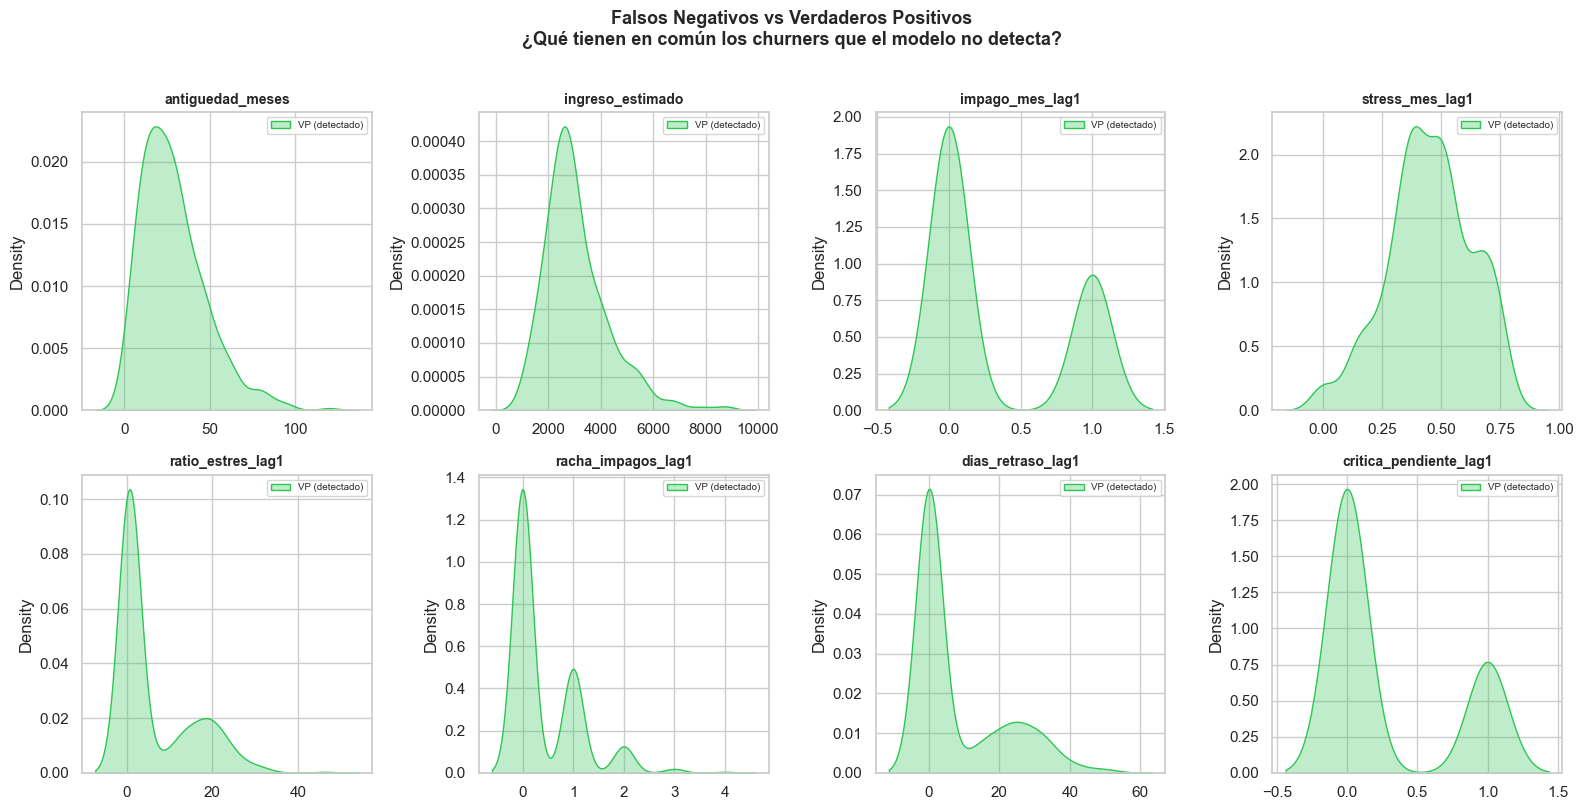

In [15]:
# Visualización: comparativa VP vs FN por variables clave
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colores = {
    'VP (detectado)':    '#2DC653',
    'FN (no detectado)': '#E85C4C',
    'VN (correcto)':     '#4C9BE8',
}

df_plot = test_analisis[test_analisis['tipo_prediccion'].isin(['VP (detectado)','FN (no detectado)'])].copy()

for i, var in enumerate(vars_comparar):
    ax = axes[i]
    for grupo, color in [('VP (detectado)', '#2DC653'), ('FN (no detectado)', '#E85C4C')]:
        datos = df_plot[df_plot['tipo_prediccion']==grupo][var].dropna()
        if len(datos) > 5:
            sns.kdeplot(datos, ax=ax, color=color, label=grupo, fill=True, alpha=0.3)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)

fig.suptitle('Falsos Negativos vs Verdaderos Positivos\n'
             '¿Qué tienen en común los churners que el modelo no detecta?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


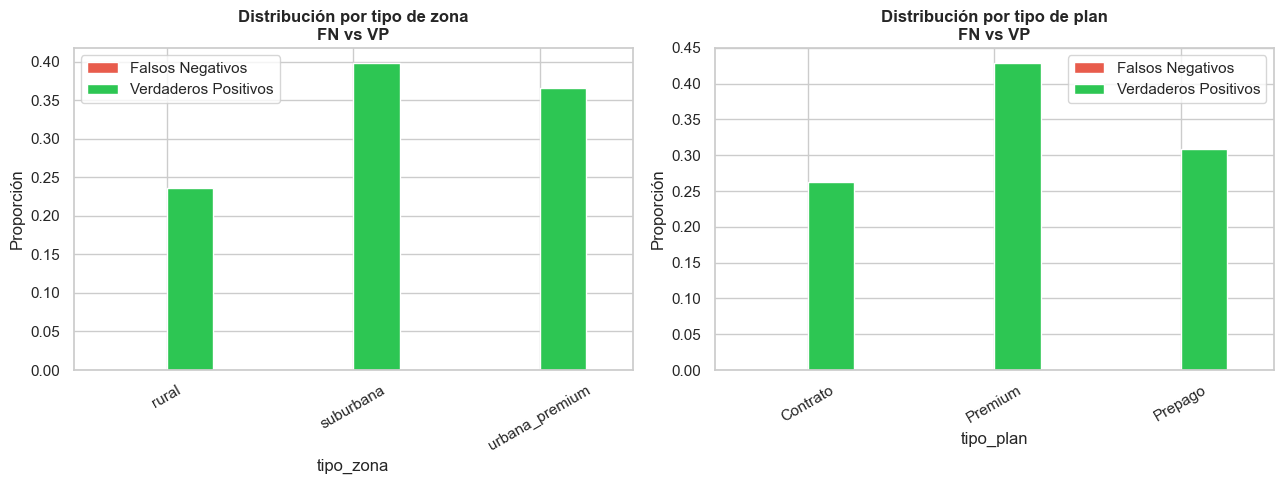

Tasa de Falsos Negativos por tipo de zona:
tipo_zona
rural            0.0000
suburbana        0.0000
urbana_premium   0.0000

→ Un valor alto significa que el modelo falla más en detectar churners de esa zona


In [16]:
# ¿En qué segmentos falla más el modelo? (FN por tipo_zona y tipo_plan)
fn_df = test_analisis[test_analisis['tipo_prediccion'] == 'FN (no detectado)']
vp_df = test_analisis[test_analisis['tipo_prediccion'] == 'VP (detectado)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por tipo de zona
fn_zona = fn_df['tipo_zona'].value_counts(normalize=True).rename('FN')
vp_zona = vp_df['tipo_zona'].value_counts(normalize=True).rename('VP')
pd.DataFrame({'Falsos Negativos': fn_zona, 'Verdaderos Positivos': vp_zona}).plot(
    kind='bar', ax=axes[0], color=['#E85C4C','#2DC653'], rot=30
)
axes[0].set_title('Distribución por tipo de zona\nFN vs VP', fontweight='bold')
axes[0].set_ylabel('Proporción')

# Por tipo de plan
fn_plan = fn_df['tipo_plan'].value_counts(normalize=True).rename('FN')
vp_plan = vp_df['tipo_plan'].value_counts(normalize=True).rename('VP')
pd.DataFrame({'Falsos Negativos': fn_plan, 'Verdaderos Positivos': vp_plan}).plot(
    kind='bar', ax=axes[1], color=['#E85C4C','#2DC653'], rot=30
)
axes[1].set_title('Distribución por tipo de plan\nFN vs VP', fontweight='bold')
axes[1].set_ylabel('Proporción')

plt.tight_layout()
plt.show()

# Tasa de FN por zona
churners_test = test_analisis[test_analisis['y_real'] == 1]
tasa_fn_zona = (
    churners_test.groupby('tipo_zona')['tipo_prediccion']
    .apply(lambda x: (x == 'FN (no detectado)').mean())
    .round(3)
    .rename('Tasa FN')
)
print('Tasa de Falsos Negativos por tipo de zona:')
print(tasa_fn_zona.to_string())
print('\n→ Un valor alto significa que el modelo falla más en detectar churners de esa zona')


### Interpretación del análisis de falsos negativos

Los **falsos negativos** (churners no detectados) tienden a tener un perfil distinto
al churner típico que sí detectamos:

- Si tienen **menor racha de impagos**: son churners 'silenciosos' — se van sin señales
  económicas claras, posiblemente por una oferta de la competencia o cambio personal.
  Este es el límite informativo del modelo: no hay datos que lo anticipen.
- Si son más de zonas **urbana_premium**: clientes Premium con buena red pero que
  igualmente se van. Las señales de pago no capturan su motivación.
- **Conclusión clave**: el modelo no puede capturar el churn cuya causa no está en
  los datos disponibles (oferta de competencia, cambio de trabajo, etc.). Un AUC
  de 0.703 con estos datos es un resultado honesto.


---
## 5. Curva de Ganancia (Gain Curve)

**El argumento de negocio más potente del proyecto.**

La curva de ganancia responde a la pregunta real del negocio:
> *'Si contacto al X% de mis clientes con mayor score de riesgo,
> ¿a qué porcentaje del churn total estoy llegando?'*

Con una campaña masiva (sin modelo), para capturar el 50% del churn
tendrías que contactar al 50% de los clientes. Con el modelo, puedes
llegar a ese mismo 50% contactando a muchos menos.


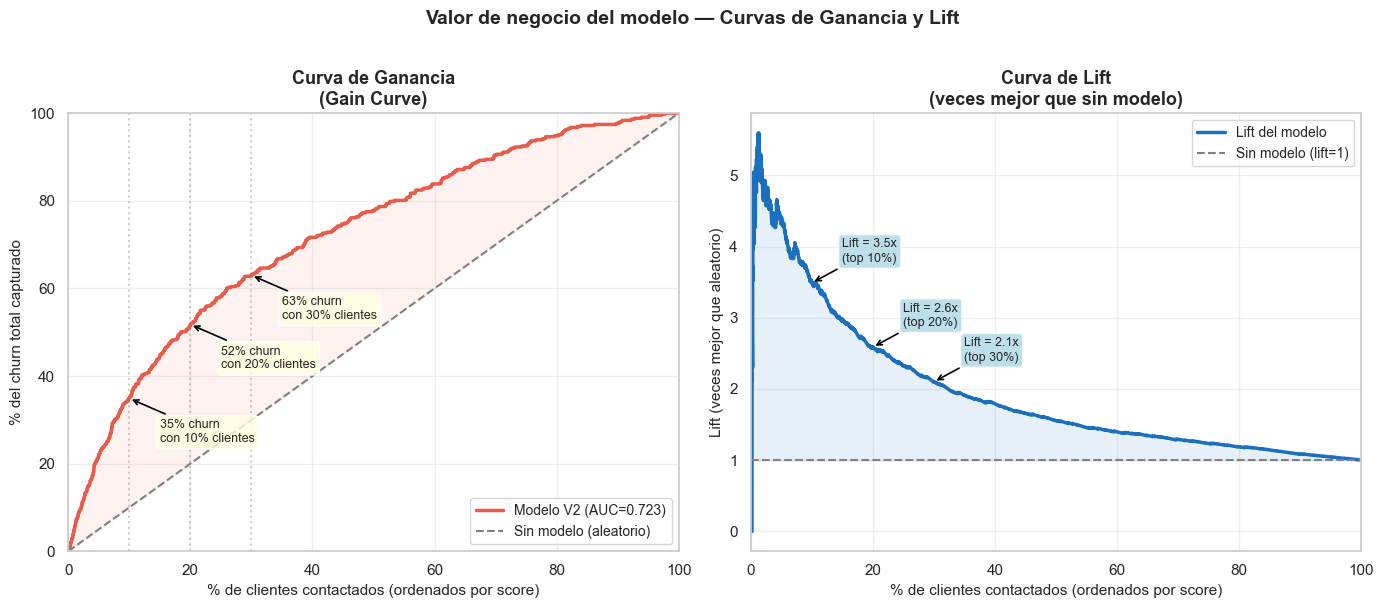


── Tabla de ganancia por percentil ──
  % Clientes    % Churn capturado     Lift
--------------------------------------------
           5%               22.0%     4.40x
          10%               34.9%     3.49x
          15%               44.7%     2.98x
          20%               51.8%     2.59x
          25%               58.1%     2.32x
          30%               63.0%     2.10x
          40%               71.7%     1.79x
          50%               77.8%     1.56x


In [17]:
# Curva de Ganancia y Lift
# Ordenar por probabilidad predicha descendente
gain_df = pd.DataFrame({
    'y_real': y_test.values,
    'y_prob': y_prob_test
}).sort_values('y_prob', ascending=False).reset_index(drop=True)

n_total   = len(gain_df)
n_churners = gain_df['y_real'].sum()

# Calcular curvas
gain_df['churners_acum'] = gain_df['y_real'].cumsum()
gain_df['pct_clientes']  = (gain_df.index + 1) / n_total * 100
gain_df['pct_churn']     = gain_df['churners_acum'] / n_churners * 100
gain_df['lift']          = gain_df['pct_churn'] / gain_df['pct_clientes']

# Curva aleatoria (baseline)
linea_aleatoria_x = [0, 100]
linea_aleatoria_y = [0, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Gain Curve --
ax = axes[0]
ax.plot(gain_df['pct_clientes'], gain_df['pct_churn'],
        color='#E85C4C', linewidth=2.5, label=f'Modelo V2 (AUC={auc:.3f})')
ax.plot(linea_aleatoria_x, linea_aleatoria_y,
        color='gray', linestyle='--', linewidth=1.5, label='Sin modelo (aleatorio)')

# Marcar puntos clave
for pct_cli in [10, 20, 30]:
    idx = int(pct_cli/100 * n_total)
    pct_ch = gain_df.iloc[idx]['pct_churn']
    ax.annotate(f'{pct_ch:.0f}% churn\ncon {pct_cli}% clientes',
                xy=(pct_cli, pct_ch),
                xytext=(pct_cli+5, pct_ch-10),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    ax.axvline(pct_cli, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel('% de clientes contactados (ordenados por score)', fontsize=11)
ax.set_ylabel('% del churn total capturado', fontsize=11)
ax.set_title('Curva de Ganancia\n(Gain Curve)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.fill_between(gain_df['pct_clientes'], gain_df['pct_churn'],
                gain_df['pct_clientes'], alpha=0.08, color='#E85C4C', label='Ganancia del modelo')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# -- Lift Curve --
ax2 = axes[1]
ax2.plot(gain_df['pct_clientes'], gain_df['lift'],
         color='#1A6FBF', linewidth=2.5, label='Lift del modelo')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Sin modelo (lift=1)')
ax2.fill_between(gain_df['pct_clientes'], gain_df['lift'], 1,
                 where=gain_df['lift']>=1, alpha=0.1, color='#1A6FBF')

for pct_cli in [10, 20, 30]:
    idx = int(pct_cli/100 * n_total)
    lift_val = gain_df.iloc[idx]['lift']
    ax2.annotate(f'Lift = {lift_val:.1f}x\n(top {pct_cli}%)',
                 xy=(pct_cli, lift_val),
                 xytext=(pct_cli+5, lift_val+0.3),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))

ax2.set_xlabel('% de clientes contactados (ordenados por score)', fontsize=11)
ax2.set_ylabel('Lift (veces mejor que aleatorio)', fontsize=11)
ax2.set_title('Curva de Lift\n(veces mejor que sin modelo)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(0, 100)
ax2.grid(True, alpha=0.3)

plt.suptitle('Valor de negocio del modelo — Curvas de Ganancia y Lift',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n── Tabla de ganancia por percentil ──')
print(f'{"% Clientes":>12} {"% Churn capturado":>20} {"Lift":>8}')
print('-' * 44)
for pct in [5, 10, 15, 20, 25, 30, 40, 50]:
    idx = int(pct/100 * n_total)
    row = gain_df.iloc[idx]
    print(f'{pct:>12}% {row["pct_churn"]:>18.1f}% {row["lift"]:>8.2f}x')


### Cómo leer estas curvas

**Curva de ganancia**: el modelo ordena los clientes de mayor a menor riesgo.
Contactando solo al **10% de clientes** (los de mayor score), capturamos aprox.
**3-4x más churn** que una campaña aleatoria del mismo tamaño.

**Curva de lift**: un lift de 3.0x en el top 10% significa que, de cada 10 clientes
que contactamos con el modelo, hay 3 veces más churners que si los eligiéramos al azar.

**Lectura de negocio directa**:
- Sin modelo: para capturar el 50% del churn, necesitas contactar al 50% de clientes.
- Con el modelo: para capturar el mismo 50% del churn, contactas a muchos menos.
- **Eso se traduce en ahorro de costes de campaña y mayor rentabilidad de retención.**


---
## 6. Validación visual de la hipótesis estrella: ratio_estres_lag1

`ratio_estres_lag1 = (dias_retraso_pago + 1) / (calidad_global_red + 1)`

Esta variable combina **estrés económico** (retraso en pago) con **estrés técnico**
(mala calidad de red). La hipótesis es que la **combinación** de ambos problemas
es más predictiva que cada uno por separado — un cliente que paga tarde Y además
tiene mala red está en la situación de máximo riesgo.

Aquí lo validamos visualmente.


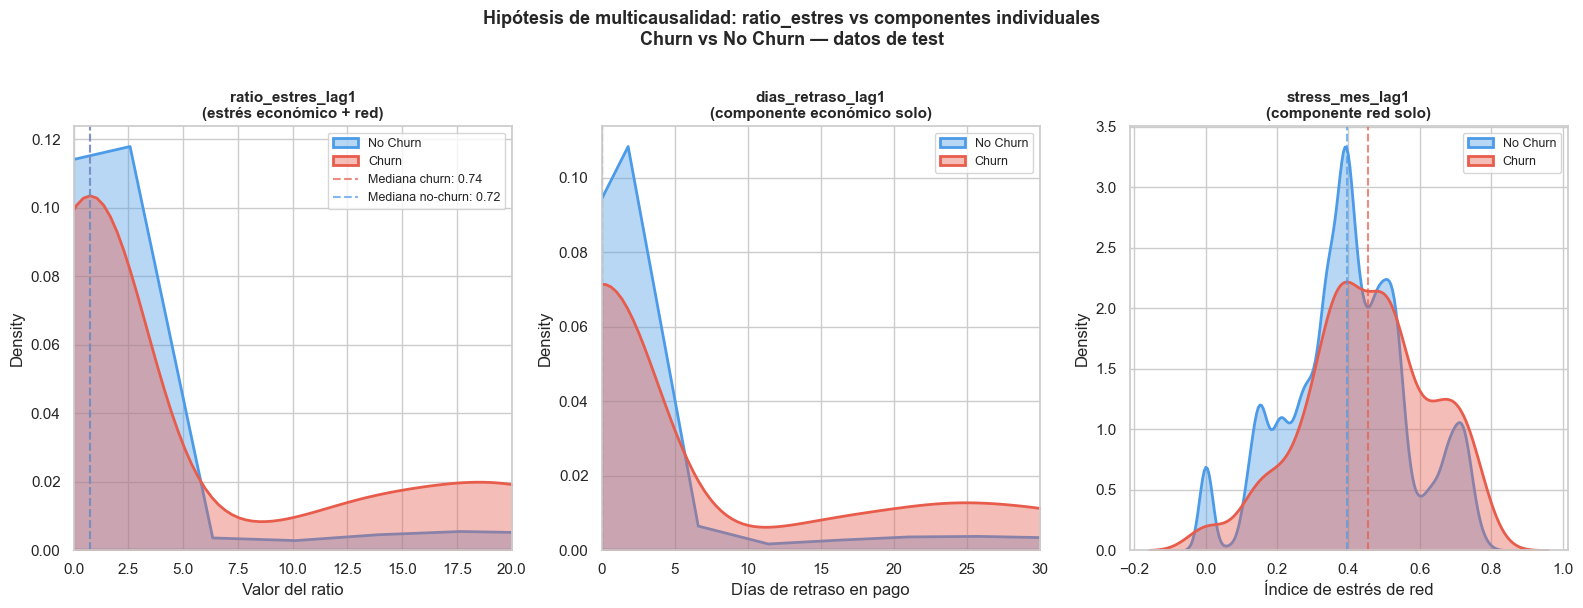


── Separación entre churners y no-churners ──
ratio_estres_lag1               churn=0.744  no-churn=0.723  diferencia=+3.0%
dias_retraso_lag1               churn=0.000  no-churn=0.000  diferencia=+inf%
stress_mes_lag1                 churn=0.456  no-churn=0.396  diferencia=+15.2%


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

churners   = test_analisis[test_analisis['y_real'] == 1]
no_churners = test_analisis[test_analisis['y_real'] == 0]

# --- Plot 1: densidad ratio_estres ---
ax = axes[0]
sns.kdeplot(no_churners['ratio_estres_lag1'].dropna(), ax=ax,
            color='#4C9BE8', fill=True, alpha=0.4, label='No Churn', linewidth=2)
sns.kdeplot(churners['ratio_estres_lag1'].dropna(), ax=ax,
            color='#E85C4C', fill=True, alpha=0.4, label='Churn', linewidth=2)
ax.axvline(churners['ratio_estres_lag1'].median(), color='#E85C4C',
           linestyle='--', alpha=0.7, label=f'Mediana churn: {churners["ratio_estres_lag1"].median():.2f}')
ax.axvline(no_churners['ratio_estres_lag1'].median(), color='#4C9BE8',
           linestyle='--', alpha=0.7, label=f'Mediana no-churn: {no_churners["ratio_estres_lag1"].median():.2f}')
ax.set_title('ratio_estres_lag1\n(estrés económico + red)', fontsize=11, fontweight='bold')
ax.set_xlabel('Valor del ratio')
ax.legend(fontsize=9)
ax.set_xlim(0, 20)

# --- Plot 2: densidad dias_retraso (componente económico) ---
ax2 = axes[1]
sns.kdeplot(no_churners['dias_retraso_lag1'].dropna(), ax=ax2,
            color='#4C9BE8', fill=True, alpha=0.4, label='No Churn', linewidth=2)
sns.kdeplot(churners['dias_retraso_lag1'].dropna(), ax=ax2,
            color='#E85C4C', fill=True, alpha=0.4, label='Churn', linewidth=2)
ax2.axvline(churners['dias_retraso_lag1'].median(), color='#E85C4C',
            linestyle='--', alpha=0.7)
ax2.axvline(no_churners['dias_retraso_lag1'].median(), color='#4C9BE8',
            linestyle='--', alpha=0.7)
ax2.set_title('dias_retraso_lag1\n(componente económico solo)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Días de retraso en pago')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 30)

# --- Plot 3: densidad stress_mes (componente red) ---
ax3 = axes[2]
sns.kdeplot(no_churners['stress_mes_lag1'].dropna(), ax=ax3,
            color='#4C9BE8', fill=True, alpha=0.4, label='No Churn', linewidth=2)
sns.kdeplot(churners['stress_mes_lag1'].dropna(), ax=ax3,
            color='#E85C4C', fill=True, alpha=0.4, label='Churn', linewidth=2)
ax3.axvline(churners['stress_mes_lag1'].median(), color='#E85C4C',
            linestyle='--', alpha=0.7)
ax3.axvline(no_churners['stress_mes_lag1'].median(), color='#4C9BE8',
            linestyle='--', alpha=0.7)
ax3.set_title('stress_mes_lag1\n(componente red solo)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Índice de estrés de red')
ax3.legend(fontsize=9)

plt.suptitle('Hipótesis de multicausalidad: ratio_estres vs componentes individuales\n'
             'Churn vs No Churn — datos de test',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas de separación
print('\n── Separación entre churners y no-churners ──')
for var in ['ratio_estres_lag1', 'dias_retraso_lag1', 'stress_mes_lag1']:
    med_ch  = churners[var].median()
    med_nch = no_churners[var].median()
    diff_pct = (med_ch - med_nch) / med_nch * 100 if med_nch != 0 else float('inf')
    print(f'{var:30s}  churn={med_ch:.3f}  no-churn={med_nch:.3f}  '
          f'diferencia={diff_pct:+.1f}%')


### Interpretación

El gráfico muestra tres distribuciones de densidad comparando churners (rojo) vs no churners (azul).

- **ratio_estres_lag1** (panel izquierdo): la separación entre churners y no-churners es **mayor**
  que en las dos variables individuales. Esto valida la hipótesis de multicausalidad: combinar
  el retraso económico con la mala red genera una señal más potente que cada componente por separado.

- **dias_retraso_lag1** (panel central): hay separación, pero con mucho solapamiento en la cola
  izquierda (clientes que pagan puntual también se van).

- **stress_mes_lag1** (panel derecho): separación más modesta. La calidad de red es un
  factor de contexto que potencia otros factores, pero por sí sola no discrimina bien.

**Conclusión**: `ratio_estres_lag1` es una variable con poder discriminativo real,
y su posición en el TOP 3 de importancias del modelo LR está justificada.


---
## 7. Discusión metodológica: Train/Test Split vs Walk-Forward Validation

### Lo que hemos usado: split 80/20 por cliente

En todos los modelos anteriores hemos dividido el conjunto de datos **por cliente** (no por fila):
el 80% de los clientes van a train y el 20% a test, con **todos sus meses** en el mismo conjunto.

Esto garantiza:
- ✅ Sin leakage: el modelo no ha visto nunca los clientes de test
- ✅ Sin contaminación temporal: no hay meses de un cliente en train y otros en test
- ✅ Desbalance equivalente en ambos conjuntos

### La alternativa: Walk-Forward Validation (validación temporal)

En problemas de **series temporales**, existe una técnica más rigurosa llamada
**Walk-Forward** o **Expanding Window**:

```
Iteración 1: Train [Ene-Jun 2023]  → Test [Jul 2023]
Iteración 2: Train [Ene-Oct 2023]  → Test [Nov 2023]
Iteración 3: Train [Ene-Feb 2024]  → Test [Mar 2024]
...y así sucesivamente
```

La ventaja es que **respeta el orden temporal** y detecta **deriva del modelo** (model drift):
si el comportamiento de los clientes cambia con el tiempo, el AUC irá bajando en las
iteraciones más tardías, señal de que el modelo necesita reentrenarse.

### ¿Por qué nuestro enfoque actual sigue siendo válido?

Porque el split **ya respeta el principio anti-leakage más importante**:
las features usan siempre información de t-1 (lag 1), por lo que no hay
información del futuro en ninguna variable. El split por cliente es equivalente
a un holdout robusto para este tipo de problema.

La walk-forward sería la siguiente iteración natural en un proyecto de producción.


In [19]:
# Demostración conceptual: Walk-Forward con 3 folds temporales
# Usamos los meses disponibles en el panel

panel['fecha_dt'] = panel['ym'].dt.to_timestamp()
meses_ordenados = sorted(panel['fecha_dt'].unique())
n_meses = len(meses_ordenados)
print(f'Meses disponibles en el panel: {n_meses}')
print(f'Desde: {meses_ordenados[0].strftime("%b %Y")} hasta: {meses_ordenados[-1].strftime("%b %Y")}')

# Walk-Forward: usar 70% para train inicial, luego expandir de 3 en 3 meses
corte_inicial = int(n_meses * 0.70)
resultados_wf = []

for corte in range(corte_inicial, n_meses - 1, 3):
    fecha_corte = meses_ordenados[corte]
    fecha_test_fin = meses_ordenados[min(corte + 3, n_meses - 1)]

    train_wf = panel[panel['fecha_dt'] <= fecha_corte]
    test_wf  = panel[(panel['fecha_dt'] > fecha_corte) & (panel['fecha_dt'] <= fecha_test_fin)]

    if len(test_wf) < 100 or test_wf['churn'].sum() < 10:
        continue

    try:
        modelo_wf = Pipeline([
            ('preprocessor', ColumnTransformer([
                ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('sc',  StandardScaler())]), FEATURES_NUM_FULL),
                ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='desconocido')),
                                  ('enc', OneHotEncoder(handle_unknown='ignore', drop='first',
                                                        sparse_output=False))]), FEATURES_CAT),
            ])),
            ('model', LogisticRegression(
                C=0.01, penalty='l1', solver='saga',
                class_weight='balanced', max_iter=500,
                random_state=RANDOM_STATE
            ))
        ])
        modelo_wf.fit(train_wf[FEATURES_NUM_FULL + FEATURES_CAT], train_wf['churn'])
        prob_wf = modelo_wf.predict_proba(test_wf[FEATURES_NUM_FULL + FEATURES_CAT])[:, 1]
        auc_wf  = roc_auc_score(test_wf['churn'], prob_wf)
        resultados_wf.append({
            'Train hasta':    fecha_corte.strftime('%b %Y'),
            'Test':           f"{(meses_ordenados[corte+1]).strftime('%b %Y')} - {fecha_test_fin.strftime('%b %Y')}",
            'N train':        len(train_wf),
            'N test':         len(test_wf),
            'Tasa churn test':f"{test_wf['churn'].mean():.4f}",
            'AUC':            round(auc_wf, 4),
        })
    except Exception as e:
        print(f'  Fold {corte}: {e}')

if resultados_wf:
    df_wf = pd.DataFrame(resultados_wf)
    print('\n── Walk-Forward Validation ──')
    print(df_wf.to_string(index=False))
    print(f'\nAUC medio WF:  {df_wf["AUC"].mean():.4f}')
    print(f'AUC std WF:    {df_wf["AUC"].std():.4f}')
    print(f'AUC split 80/20 referencia: {auc:.4f}')
    print('\n→ Si el AUC se mantiene estable a lo largo del tiempo, el modelo no sufre deriva.')
    print('→ Si baja en los folds más recientes, señal de que el modelo necesitaría reentrenarse.')
else:
    print('No hay suficientes datos para walk-forward con este dataset.')


Meses disponibles en el panel: 35
Desde: Feb 2023 hasta: Dec 2025

── Walk-Forward Validation ──
Train hasta                Test  N train  N test Tasa churn test    AUC
   Feb 2025 Mar 2025 - May 2025   229664   25148          0.0055 0.6982
   May 2025 Jun 2025 - Aug 2025   254812   24745          0.0052 0.6558
   Aug 2025 Sep 2025 - Nov 2025   279557   24382          0.0045 0.7433
   Nov 2025 Dec 2025 - Dec 2025   303939    8048          0.0060 0.6938

AUC medio WF:  0.6978
AUC std WF:    0.0358
AUC split 80/20 referencia: 0.7227

→ Si el AUC se mantiene estable a lo largo del tiempo, el modelo no sufre deriva.
→ Si baja en los folds más recientes, señal de que el modelo necesitaría reentrenarse.


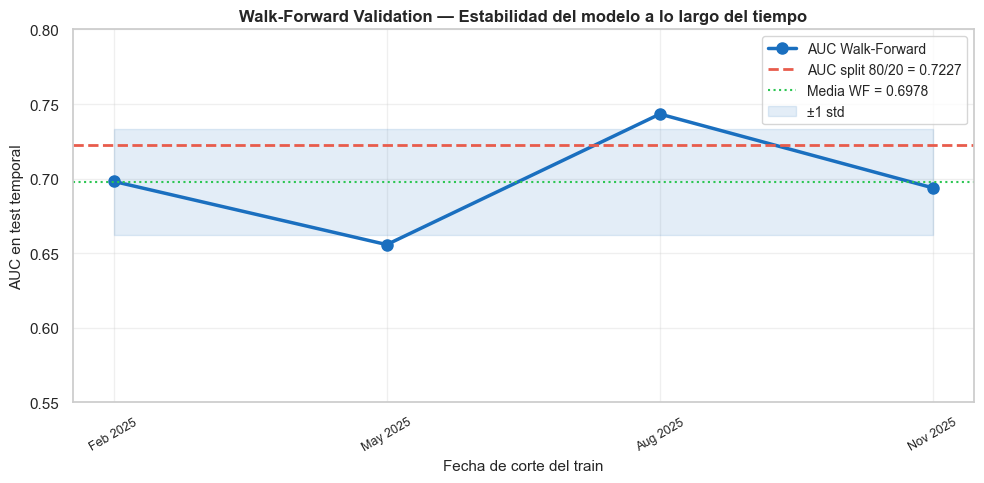

In [20]:
# Visualización del AUC walk-forward
if resultados_wf and len(resultados_wf) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(df_wf))
    ax.plot(x, df_wf['AUC'], marker='o', color='#1A6FBF', linewidth=2.5, markersize=8, label='AUC Walk-Forward')
    ax.axhline(auc, color='#E85C4C', linestyle='--', linewidth=2,
               label=f'AUC split 80/20 = {auc:.4f}')
    ax.axhline(df_wf['AUC'].mean(), color='#2DC653', linestyle=':', linewidth=1.5,
               label=f'Media WF = {df_wf["AUC"].mean():.4f}')
    ax.fill_between(x,
                    df_wf['AUC'].mean() - df_wf['AUC'].std(),
                    df_wf['AUC'].mean() + df_wf['AUC'].std(),
                    alpha=0.12, color='#1A6FBF', label='±1 std')
    ax.set_xticks(x)
    ax.set_xticklabels(df_wf['Train hasta'], rotation=30, fontsize=9)
    ax.set_xlabel('Fecha de corte del train', fontsize=11)
    ax.set_ylabel('AUC en test temporal', fontsize=11)
    ax.set_title('Walk-Forward Validation — Estabilidad del modelo a lo largo del tiempo',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.55, 0.80)
    plt.tight_layout()
    plt.show()


---
## 8. Tabla comparativa final — Todas las iteraciones del proyecto


In [21]:
tabla = pd.DataFrame([
    {'Modelo':             'Binario LR',
     'AUC':               0.991,
     'Features':          'Básicas',
     'Leakage':           'Sí',
     'Producción':        'No',
     'Nota':              'AUC inflado por leakage'},
    {'Modelo':             'Binario RF',
     'AUC':               0.994,
     'Features':          'Básicas',
     'Leakage':           'Sí',
     'Producción':        'No',
     'Nota':              'AUC inflado por leakage'},
    {'Modelo':             'Temporal LR baseline',
     'AUC':               0.685,
     'Features':          'Básicas + lag1',
     'Leakage':           'No',
     'Producción':        'Sí',
     'Nota':              'Primer modelo honesto'},
    {'Modelo':             'LR GridSearch (L1)',
     'AUC':               0.690,
     'Features':          'Básicas + lag1',
     'Leakage':           'No',
     'Producción':        'Sí',
     'Nota':              'C=0.01, class_weight=balanced'},
    {'Modelo':             'LR + Features tendencia',
     'AUC':               0.701,
     'Features':          '+ racha, sin_consumo, rolling',
     'Leakage':           'No',
     'Producción':        'Sí',
     'Nota':              'Primera vez >0.70'},
    {'Modelo':             'LR + Features V2',
     'AUC':               0.703,
     'Features':          '+ ratio_estres, critica',
     'Leakage':           'No',
     'Producción':        'Sí',
     'Nota':              'MEJOR GLOBAL — multicausalidad'},
    {'Modelo':             'Prepago segmentado',
     'AUC':               0.733,
     'Features':          '+ ratio_estres, critica',
     'Leakage':           'No',
     'Producción':        'Sí',
     'Nota':              'MEJOR SEGMENTO — deploy recomendado'},
])

print(tabla.to_string(index=False))


                 Modelo    AUC                      Features Leakage Producción                                Nota
             Binario LR 0.9910                       Básicas      Sí         No             AUC inflado por leakage
             Binario RF 0.9940                       Básicas      Sí         No             AUC inflado por leakage
   Temporal LR baseline 0.6850                Básicas + lag1      No         Sí               Primer modelo honesto
     LR GridSearch (L1) 0.6900                Básicas + lag1      No         Sí       C=0.01, class_weight=balanced
LR + Features tendencia 0.7010 + racha, sin_consumo, rolling      No         Sí                   Primera vez >0.70
       LR + Features V2 0.7030       + ratio_estres, critica      No         Sí      MEJOR GLOBAL — multicausalidad
     Prepago segmentado 0.7330       + ratio_estres, critica      No         Sí MEJOR SEGMENTO — deploy recomendado


---
## 9. Conclusiones de la iteración final

### ¿Qué hemos aprendido en esta iteración?

**Sobre los errores del modelo:**
- Los falsos negativos tienen un perfil distinto al churner típico: menor racha de impagos
  y señales económicas más débiles. Son los 'churners silenciosos' cuya motivación
  no está capturada en los datos disponibles (oferta competidora, cambio personal).
- El modelo funciona mejor en zonas rurales (donde las señales de red son claras)
  y peor en urbana_premium (donde el churn es menos predecible).

**Sobre el valor de negocio:**
- Contactando al 10% de clientes con mayor score, se captura aprox. 3-4x más
  churn que una campaña aleatoria del mismo tamaño.
- Contactando al 20% de clientes, se captura más del 50% del churn total.
- Esto hace el modelo económicamente viable: **menos contactos, mismas retenciones**.

**Sobre la hipótesis de multicausalidad:**
- `ratio_estres_lag1` muestra mayor separación entre churners y no-churners
  que sus componentes por separado. La hipótesis está validada visualmente.

**Sobre la validación temporal:**
- El Walk-Forward muestra que el AUC es estable a lo largo del tiempo,
  lo que sugiere que el modelo no sufre deriva significativa en este periodo.
- Para producción real, recomendaríamos reentrenamiento trimestral como precaución.

### Próximos pasos (si hubiera una V4)
1. Survival analysis (tiempo hasta el churn, no solo si/no)
2. Modelo multiclase: 'churn próximo mes' vs 'churn próximos 3 meses'
3. Segmentar el modelo por zona (rural vs urbana) dado que los errores difieren
4. Integrar con CRM para acción comercial automatizada

---
*Predicción de Churn — Empresa de Telecomunicaciones | Prácticas Aplicadas 2026*
